In [6]:
import numpy as np
import subprocess
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys
from pathlib import Path

root = Path.cwd().resolve().parent
sys.path.insert(0, str(root))
print("Setting root of the project to:", root)
print("This means we can bring in models from other directories (like ./models)")

def sampleAndSimulate(alpha, beta, seed=42):
    gamma_samples = np.random.default_rng(seed=seed).gamma(shape=alpha, scale=1/alpha, size=10_000)
    s_samples = gamma_samples - 1
    pd.DataFrame(gamma_samples).to_csv('../slim/inputs/gamma_distributed_sample.csv', index=False, header=False)

    # Find fitness coefficients that work
    print("Simulating ...")
    result = subprocess.run(['slim', '-x', '../slim/simulate_one.slim'], capture_output=True, text=True)
    # print(result.stdout)
    if result.stderr:
        print("STDERR:\n", result.stderr)

    print("Simulation complete - reading files ...")
    sim_df = pd.DataFrame()
    
    sim_df['position'] = pd.read_csv("../slim/inputs/admixture_mapping_targets.csv", header=None)
    for generation in range(1, 7):
        sim_i = pd.read_csv(f"../slim/tmp/65755-10000-0-_Cycle_{generation}0.txt")
        sim_df[f"sim_{generation}0"] = sim_i[f"Frequency_{generation}0"]

    # Turn mutations into allele frequencies
    for i in [10,20,30,40,50,60]:
        sim_df[f'sim_{i}'] = sim_df[f'sim_{i}'] / 200

    # Deltas
    sim_df['simdelta_20'] = sim_df['sim_20'] - sim_df['sim_10']
    sim_df['simdelta_30'] = sim_df['sim_30'] - sim_df['sim_20']
    sim_df['simdelta_40'] = sim_df['sim_40'] - sim_df['sim_30']
    sim_df['simdelta_50'] = sim_df['sim_50'] - sim_df['sim_40']
    sim_df['simdelta_60'] = sim_df['sim_60'] - sim_df['sim_50']

    # Create file
    sim_df[['alpha', 'beta']] = alpha, beta
    file_path = f"../slim/outputs/alpha={alpha}_beta={beta}.csv"
    sim_df.to_csv(path_or_buf=file_path)
    print(f"written file to {file_path}")
    
    return sim_df

Setting root of the project to: /home/kv/education/predicting_DFE
This means we can bring in models from other directories (like ./models)


In [7]:
df = sampleAndSimulate(alpha=3400, beta=1/2000)
df

Simulating ...
STDERR:
 // ********** The -x command-line option has disabled some runtime checks

20.94user 0.24system 0:21.21elapsed 99%CPU (0avgtext+0avgdata 802844maxresident)k
0inputs+432outputs (0major+201100minor)pagefaults 0swaps

Simulation complete - reading files ...
written file to ../slim/outputs/alpha=3400_beta=0.0005.csv


,position,sim_10,sim_20,sim_30,sim_40,sim_50,sim_60,simdelta_20,simdelta_30,simdelta_40,simdelta_50,simdelta_60,alpha,beta
0,10194546,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,3400,0.0005
1,10194549,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,3400,0.0005
2,10194552,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,3400,0.0005
3,10194557,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,3400,0.0005
4,10194670,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,3400,0.0005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,12509860,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,3400,0.0005
9996,12509995,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,3400,0.0005
9997,12510001,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,3400,0.0005
9998,12510011,0.02,0.0,0.0,0.0,0.0,0.0,-0.02,0.0,0.0,0.0,0.0,3400,0.0005


In [3]:
df[df.sim_60 > 0]

,position,sim_10,sim_20,sim_30,sim_40,sim_50,sim_60,simdelta_20,simdelta_30,simdelta_40,simdelta_50,simdelta_60,alpha,beta
29,10197887,7.525,10.000,10.000,10.000,10.000,10.000,2.475,0.000,0.000,0.000,0.000,3400,0.0005
170,10253903,5.285,5.090,9.305,5.265,5.770,5.715,-0.195,4.215,-4.040,0.505,-0.055,3400,0.0005
290,10290904,2.285,4.865,5.100,4.955,5.535,5.245,2.580,0.235,-0.145,0.580,-0.290,3400,0.0005
343,10303958,2.290,4.755,5.085,4.835,5.425,5.230,2.465,0.330,-0.250,0.590,-0.195,3400,0.0005
375,10309191,2.300,4.760,5.085,4.835,5.425,5.230,2.460,0.325,-0.250,0.590,-0.195,3400,0.0005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9574,12447031,2.290,4.770,4.930,4.795,5.090,4.830,2.480,0.160,-0.135,0.295,-0.260,3400,0.0005
9677,12460888,2.290,9.495,10.000,10.000,10.000,10.000,7.205,0.505,0.000,0.000,0.000,3400,0.0005
9824,12484108,2.290,9.495,10.000,10.000,10.000,10.000,7.205,0.505,0.000,0.000,0.000,3400,0.0005
9842,12486099,2.290,9.495,10.000,10.000,10.000,10.000,7.205,0.505,0.000,0.000,0.000,3400,0.0005


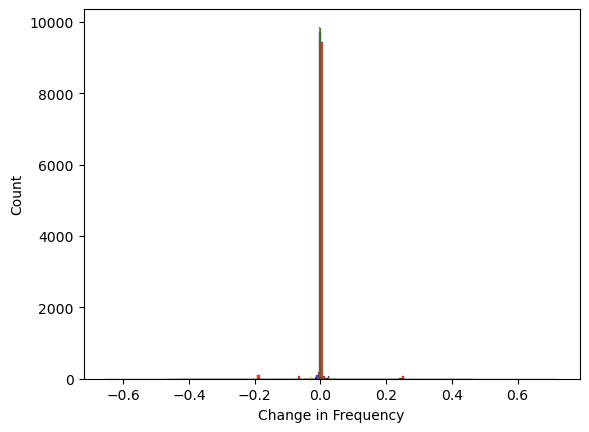

In [4]:
sns.histplot(x=df['simdelta_20'], color = 'red')
sns.histplot(x=df['simdelta_30'], color = 'blue')
sns.histplot(x=df['simdelta_40'], color = 'yellow')
sns.histplot(x=df['simdelta_50'], color = 'green')
sns.histplot(x=df['simdelta_60'], color = 'grey')
plt.xlabel("Change in Frequency")
plt.show()

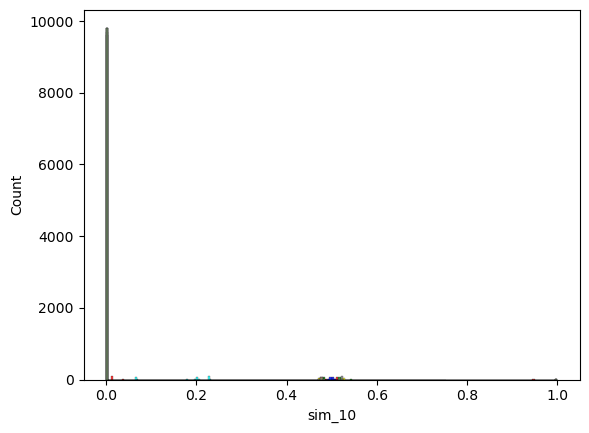

In [5]:
sns.histplot(x=df['sim_10'], color = 'cyan')
sns.histplot(x=df['sim_20'], color = 'red')
sns.histplot(x=df['sim_30'], color = 'blue')
sns.histplot(x=df['sim_40'], color = 'yellow')
sns.histplot(x=df['sim_50'], color = 'green')
sns.histplot(x=df['sim_60'], color = 'grey')
plt.show()

In [12]:
df['sim_60'][df.sim_60 > 0].count()

np.int64(185)